In [2]:
1. Klasifikasi Flynn

    Operasi arr + arr pada NumPy array: SIMD (Single Instruction, Multiple Data)

        Alasan: NumPy memanfaatkan instruksi vektor pada CPU (seperti AVX/SSE). Satu instruksi penjumlahan dieksekusi secara sejajar terhadap banyak elemen data (vektor/array) dalam satu waktu.

    Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris: SISD (Single Instruction, Single Data)

        Alasan: Program berjalan secara serial pada satu core CPU, mengeksekusi satu aliran instruksi secara berurutan untuk memproses satu data (baris) pada satu waktu.

    Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen: MIMD (Multiple Instruction, Multiple Data)

        Alasan: Setiap node pada cluster merupakan komputer independen yang mengeksekusi instruksi/kode programnya sendiri terhadap himpunan data wilayahnya masing-masing secara bersamaan.

SyntaxError: invalid syntax (1813688144.py, line 1)

   Input Size (N)  perf_counter (s)  timeit (s)
0            5000          0.002993    0.002965
1           10000          0.006948    0.006895
2           20000          0.016178    0.015882
3           40000          0.037647    0.037468


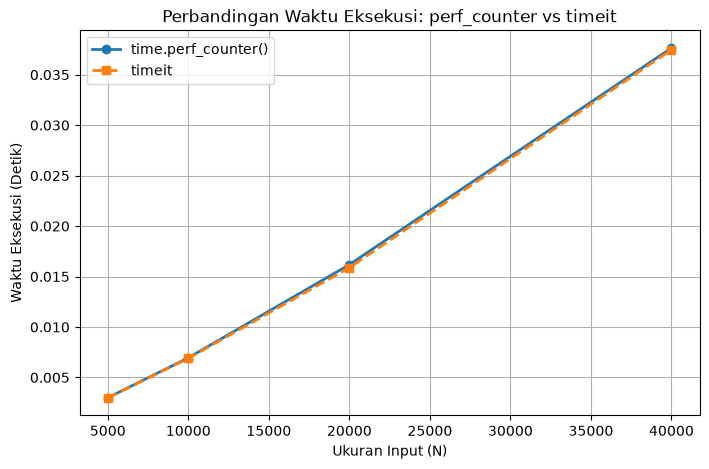

In [1]:
#2.
import time
import timeit
import matplotlib.pyplot as plt
import pandas as pd


# 1. Fungsi CPU-bound (Cek Bilangan Prima)
def hitung_prima(n):
  count = 0
  for i in range(2, n):
    is_prime = True
    for j in range(2, int(i**0.5) + 1):
      if i % j == 0:
        is_prime = False
        break
    if is_prime:
      count += 1
  return count


# 2. Ukuran input berbeda
input_sizes = [5000, 10000, 20000, 40000]
waktu_perf = []
waktu_timeit = []

# 3. Pengukuran
for n in input_sizes:
  # Pengukuran dengan time.perf_counter()
  start = time.perf_counter()
  hitung_prima(n)
  end = time.perf_counter()
  waktu_perf.append(end - start)

  # Pengukuran dengan timeit
  t = timeit.timeit(lambda: hitung_prima(n), number=1)
  waktu_timeit.append(t)

# 4. Tabel Perbandingan
df = pd.DataFrame({
    "Input Size (N)": input_sizes,
    "perf_counter (s)": waktu_perf,
    "timeit (s)": waktu_timeit,
})
print(df)

# 5. Visualisasi Plot Perbandingan
plt.figure(figsize=(8, 5))
plt.plot(
    input_sizes,
    waktu_perf,
    marker="o",
    label="time.perf_counter()",
    linewidth=2,
)
plt.plot(
    input_sizes,
    waktu_timeit,
    marker="s",
    linestyle="--",
    label="timeit",
    linewidth=2,
)
plt.xlabel("Ukuran Input (N)")
plt.ylabel("Waktu Eksekusi (Detik)")
plt.title("Perbandingan Waktu Eksekusi: perf_counter vs timeit")
plt.legend()
plt.grid(True)
plt.show()

N	Speedup
---------------
2	1.74
4	2.76
8	3.90
16	4.92
32	5.66
64	6.12


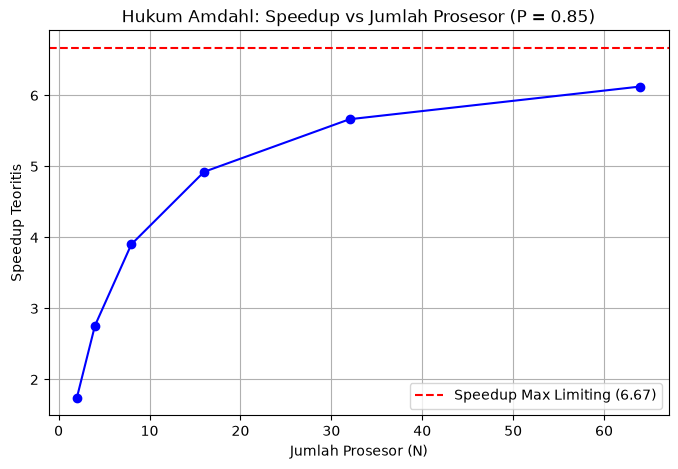

In [3]:
#3.
import matplotlib.pyplot as plt
import numpy as np


def amdahl_speedup(P, N):
  return 1 / ((1 - P) + (P / N))


P = 0.85
N_values = [2, 4, 8, 16, 32, 64]
speedups = [amdahl_speedup(P, n) for n in N_values]

# Print Tabel Hasil
print("N\tSpeedup")
print("-" * 15)
for n, s in zip(N_values, speedups):
  print(f"{n}\t{s:.2f}")

# Plot Speedup vs N
plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker="o", color="b", linestyle="-")
plt.title("Hukum Amdahl: Speedup vs Jumlah Prosesor (P = 0.85)")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup Teoritis")
plt.grid(True)
plt.axhline(
    y=1 / (1 - P),
    color="r",
    linestyle="--",
    label=f"Speedup Max Limiting ({1/(1-P):.2f})",
)
plt.legend()
plt.show()

In [4]:
4. Refleksi Singkat

Hukum Amdahl relevan digunakan saat ukuran beban kerja (workload) bersifat tetap (fixed-problem size), dan fokus utamanya adalah mempercepat durasi eksekusi menggunakan sistem paralel. Contohnya: mengoptimalkan kecepatan rendering sebuah frame video berresolusi 1080p yang sudah ditentukan.

Sebaliknya, Hukum Gustafson lebih relevan ketika ukuran masalah dapat diperbesar seiring bertambahnya sumber daya komputasi (scaled-problem size). Contohnya: simulasi prakiraan cuaca atau pelatihan model Machine Learning, di mana penambahan core prosesor dimanfaatkan untuk mengolah dataset yang jauh lebih besar dan kompleks dalam durasi waktu yang tetap.
    

SyntaxError: invalid decimal literal (3171195216.py, line 3)